# Regresión Logística: Predicción de Cumbre (Success)

Este cuaderno implementa un modelo de Regresión Logística para predecir si un escalador alcanzará la cumbre en las expediciones del Himalaya.

**Objetivo:** Predecir `success` (1 o 0) y evaluar el desempeño del modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, PrecisionRecallDisplay

# Configuración estética
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-09-22/members.csv"
df = pd.read_csv(url)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas.")

Dataset cargado: 76519 filas, 21 columnas.


### Preprocesamiento de Datos
- Imputación de edad.
- Selección de características relevantes.
- Codificación de variables categóricas.

In [3]:
# Imputar edad
df['age'] = df['age'].fillna(df['age'].median())

# Selección de variables
features = ['age', 'sex', 'year', 'season', 'hired', 'solo', 'oxygen_used']
X = df[features]
y = df['success'].astype(int)

# Definir transformaciones
categorical_features = ['sex', 'season']
numerical_features = ['age', 'year', 'hired', 'solo', 'oxygen_used']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

### Entrenamiento del Modelo

In [4]:
# División Entrenamiento/Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenar modelo con pipeline implícito (transformación + estimador)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_transformed, y_train)

print("Modelo entrenado con éxito.")

Modelo entrenado con éxito.


### Evaluación de Desempeño

In [5]:
y_pred = model.predict(X_test_transformed)
y_prob = model.predict_proba(X_test_transformed)[:, 1]

print("--- Métricas de Desempeño ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

--- Métricas de Desempeño ---
Accuracy: 0.7605
ROC-AUC: 0.7796

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.76      0.89      0.82      9464
           1       0.75      0.55      0.64      5840

    accuracy                           0.76     15304
   macro avg       0.76      0.72      0.73     15304
weighted avg       0.76      0.76      0.75     15304



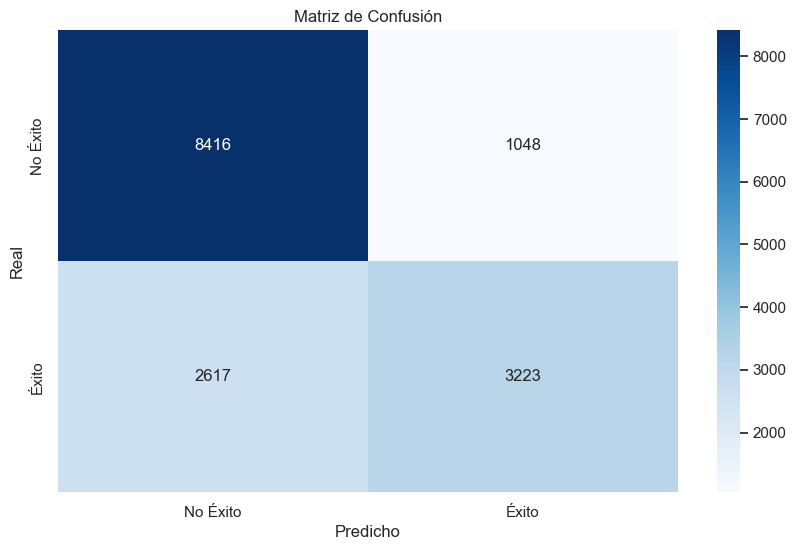

In [6]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Éxito', 'Éxito'], yticklabels=['No Éxito', 'Éxito'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

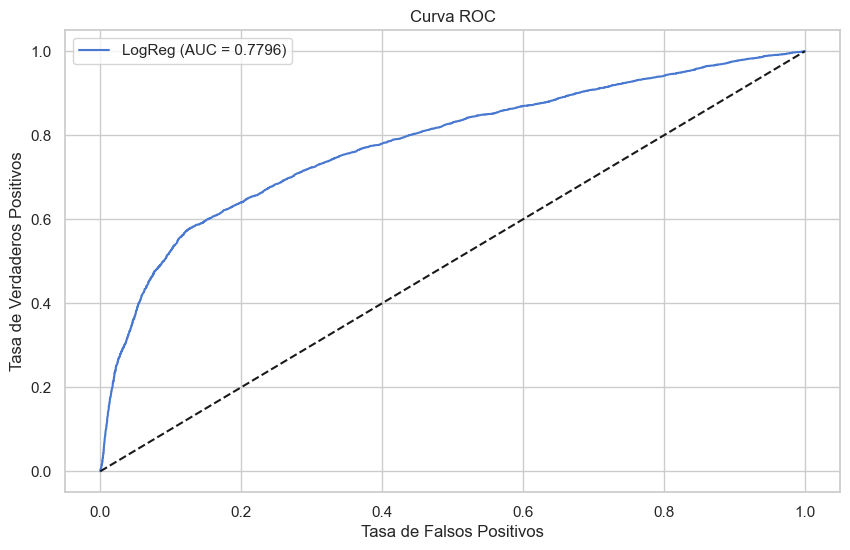

In [7]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

### Importancia de las Características (Coeficientes)

C:\Users\Arnold's\AppData\Local\Temp\ipykernel_17696\3896993233.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coeficiente', y='Variable', palette='coolwarm')


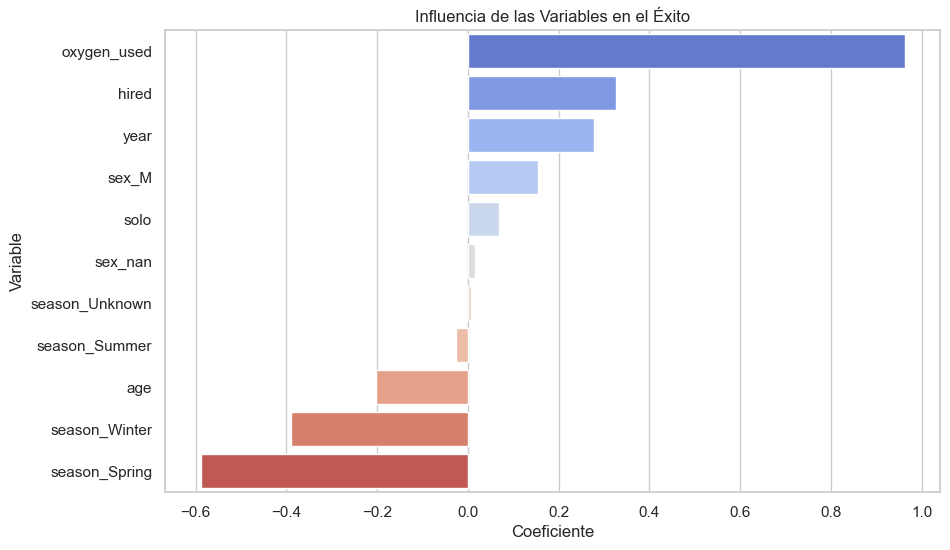

In [8]:
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_names = numerical_features + list(cat_names)

coef_df = pd.DataFrame({'Variable': all_names, 'Coeficiente': model.coef_[0]}).sort_values(by='Coeficiente', ascending=False)

sns.barplot(data=coef_df, x='Coeficiente', y='Variable', palette='coolwarm')
plt.title('Influencia de las Variables en el Éxito')
plt.show()